In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from tqdm.autonotebook import tqdm
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_3304/1253422274.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


In [2]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'non_stationary_bandits', 'params.yaml')
params = load_yaml(yaml_path)
STN_DATA_path = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')

In [3]:
TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR'] 
NUM_ARMS =params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']   
TIME_STAMP_CHANGE = params['TIME_STAMP_CHANGE']
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE

In [4]:
env = NonStationaryEnv(
    num_arms = NUM_ARMS, 
    mean_reward = np.array([20, 40, 25])/SCALING_FACTOR, #np.array([5,40,10])/SCALING_FACTOR, (20,40,10)
    std = np.array([2,2,2])/SCALING_FACTOR, 
    mean_rew_change = np.array([25, 30, 50])/SCALING_FACTOR, #np.array([10,20,60])/SCALING_FACTOR, (10,20,60)
    std_change = np.array([2,2,2])/SCALING_FACTOR, 
    time_stamp_change = TIME_STAMP_CHANGE)

BEST_ARM_BEFORE = 1
BEST_ARM_AFTER = 2

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  

In [5]:

reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, _= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = STN_DATA_path, #'rossler',
                                                      d1_amp=0.5, #0.5,
                                                      d2_amp=0.45, #0.0029, 
                                                      gpi_threshold=0.1,
                                                      max_gpi_iters=50,
                                                      del_lim=0.1, train_IP = False, 
                                                      del_med = None, printing = True,
                                                      gpi_mean= 1, ep_0 = 0.3,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0)

Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.05947437958575068, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

0: dp: tensor([[0.2503, 0.2503, 0.2503]], grad_fn=<MulBackward0>), ip: tensor([[0.4200, 0.4400, 0.4600]]), gpi: tensor([[-0.1983, -0.1985, -0.1929]], grad_fn=<NegBackward0>), arm_chosen:2
1: dp: tensor([[0.2503, 0.2503, 0.2850]], grad_fn=<MulBackward0>), ip: tensor([[0.4200, 0.4300, 0.4100]]), gpi: tensor([[-0.1884, -0.1870, -0.1647]], grad_fn=<NegBackward0>), arm_chosen:2
2: dp: tensor([[0.2503, 0.2503, 0.2608]], grad_fn=<MulBackward0>), ip: tensor([[0.4800, 0.4600, 0.4400]]), gpi: tensor([[-0.1973, -0.1951, -0.1866]], grad_fn=<NegBackward0>), arm_chosen:2
3: dp: tensor([[0.2503, 0.2503, 0.2500]], grad_fn=<MulBackward0>), ip: tensor([[0.4500, 0.4300, 0.4600]]), gpi: tensor([[-0.1986, -0.2015, -0.2002]], grad_fn=<NegBackward0>), arm_chosen:0
4: dp: tensor([[0.2500, 0.2503, 0.2500]], grad_fn=<MulBackward0>), ip: tensor([[0.4700, 0.4200, 0.3800]]), gpi: tensor([[-0.1970, -0.1979, -0.1895]], grad_fn=<NegBackward0>), arm_chosen:2
5: dp: tensor([[0.2500, 0.2503, 0.2500]], grad_fn=<MulBackwa

## Analysis

In [6]:
mean_picks = {key: torch.mean(avg_counts[key], dim = 0) for key in list(avg_counts.keys())}
IP_avg = {key: torch.mean(ip_monitor[key], dim =0).detach().numpy() for key in list(ip_monitor.keys())}
DP_avg = {key: torch.mean(dp_monitor[key], dim =0).detach().numpy() for key in list(dp_monitor.keys())}
IP_var = np.std(np.stack(list(IP_avg.values()), axis=0),axis = 0)[:,0]
arm_chosen_monitor = arm_chosen_monitor.to(torch.int)

# Computing Accuracy
optimal_probs_per_bin_all = torch.zeros((EPOCHS, BINS))

for i in range(BINS):
    start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
    correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
    optimal_probs_per_bin_all[:, i] = (correct_choices / BIN_SIZE)

optimal_prob_per_bin = torch.mean(optimal_probs_per_bin_all,axis = 0)
last_bin_prob = optimal_prob_per_bin[-1].item()
mean_prob = torch.mean(optimal_prob_per_bin).item()
mean_reward = torch.mean(reward_monitor, axis = 0)

Accuracy at last bin:  0.1080000028014183
Avg accuracy across bins:  0.22019998729228973


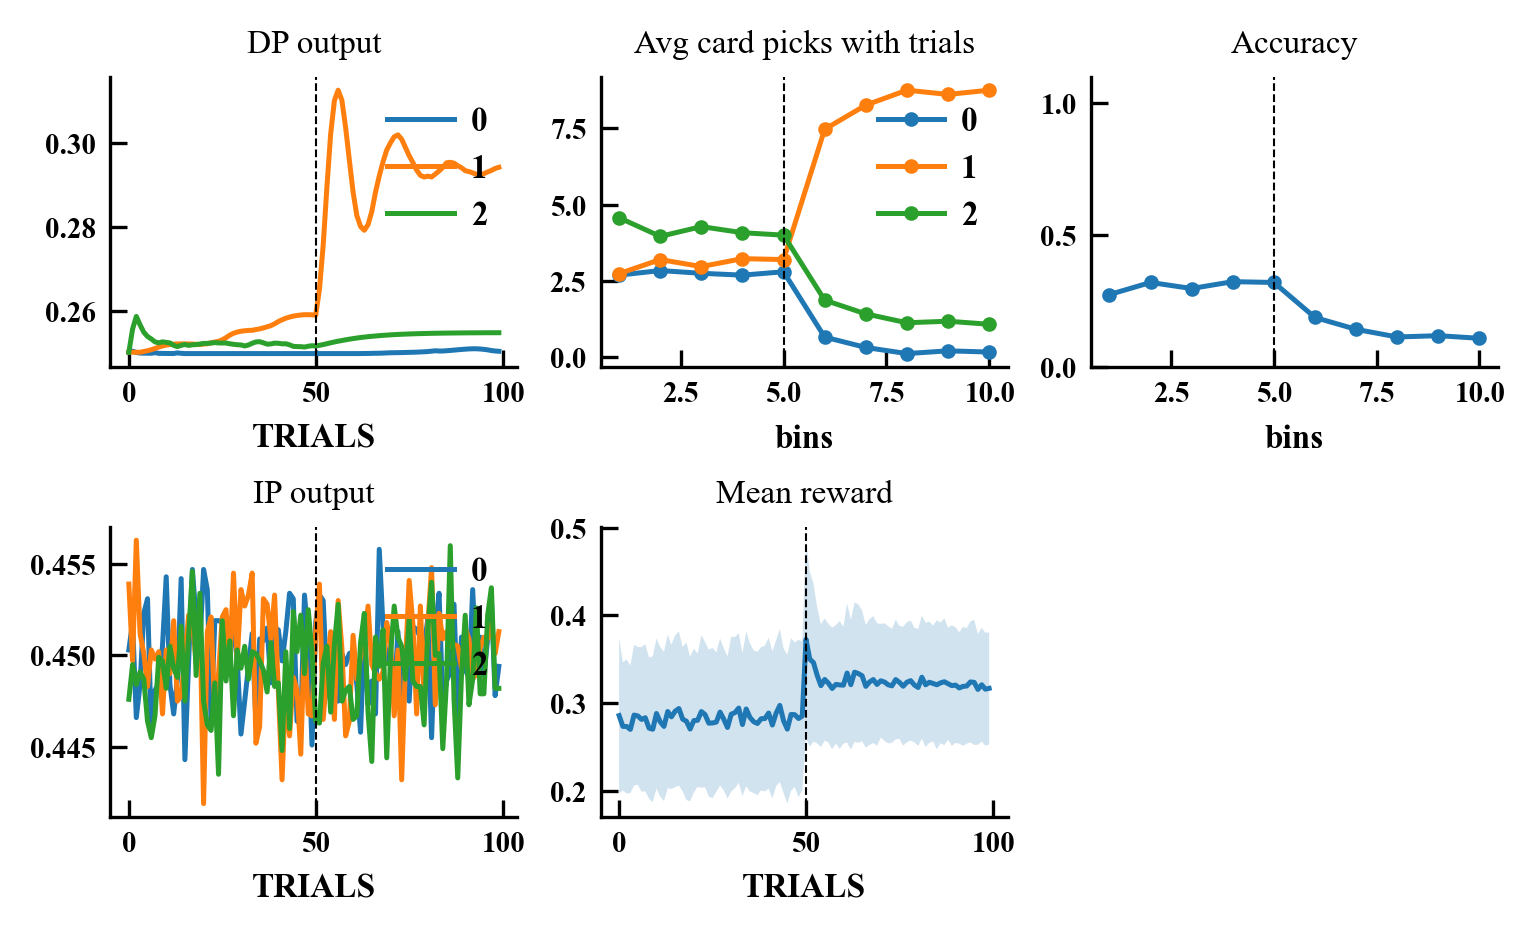

In [7]:
BIN = np.arange(BINS)+1


plt.figure(figsize=(5,3))
plt.subplot(231)
for i in DP_avg.keys():
    plt.plot(np.arange(TRIALS), DP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('TRIALS')
plt.title('DP output')
plt.legend(loc = 'upper right')

plt.subplot(232)

for i in mean_picks.keys():
    plt.plot(BIN,mean_picks[i], label = i, marker = '.', markersize = 5)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.title('Avg card picks with trials')
plt.xlabel('bins')
plt.legend(loc = 'upper right')

plt.subplot(233)
plt.plot(BIN, optimal_prob_per_bin, marker = '.', markersize = 5)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.title('Accuracy')
plt.ylim(0,1.1)
plt.xlabel('bins')

plt.subplot(234)
for i in IP_avg.keys():
    plt.plot(np.arange(TRIALS), IP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('TRIALS')
plt.title('IP output')
plt.legend(loc = 'upper right')

plt.subplot(235)
plt.plot(np.arange(TRIALS), mean_reward)
# show std as shaded region around
plt.fill_between(np.arange(TRIALS), mean_reward - torch.std(reward_monitor, axis = 0), mean_reward + torch.std(reward_monitor, axis = 0), alpha=0.2)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('TRIALS')
plt.title('Mean reward')
plt.legend(loc = 'upper right')


print('Accuracy at last bin: ',optimal_prob_per_bin[-1].item())
print('Avg accuracy across bins: ',torch.mean(optimal_prob_per_bin).item())

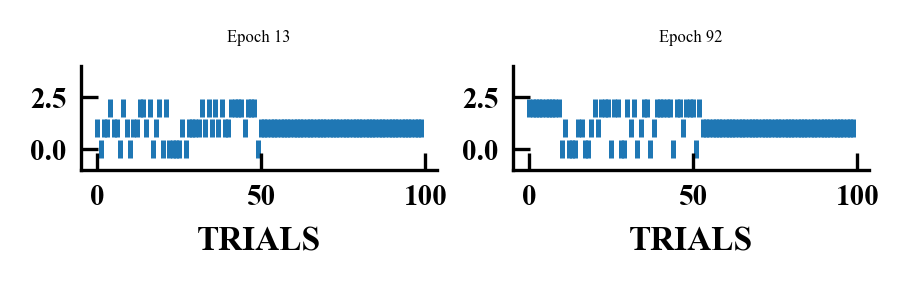

In [8]:
random_epochs = np.random.choice(np.arange(EPOCHS), size = 2)
i = 1
plt.figure(figsize=(3,1))
for e in random_epochs:
    plt.subplot(1,2,i)
    colors = np.where(np.isin(arm_chosen_monitor[e],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRIALS), arm_chosen_monitor[e], marker = '|', s = 20)
    plt.ylim(-1,4)
    plt.xlabel('TRIALS')
    plt.title(f'Epoch {e}', fontsize = 4)
    i+=1
# plt.suptitle('Card picks in each epoch')
plt.tight_layout()

In [9]:
# data = {'DP_AVG': DP_avg,
#         'IP_AVG': IP_avg,
#         'AVG_CARD_PICKS_PER_BIN': mean_picks,
#         'ARM_CHOSEN_MONITOR': arm_chosen_monitor,
#         'REWARD_MONITOR': reward_monitor,
#         'OPTIMAL_PROBS_PER_BIN': optimal_prob_per_bin,
#         'LAST_BIN_PROBS': last_bin_prob,
#         'MEAN_PROB': mean_prob,
#         'MEAN_REWARD': mean_reward 
#         }

# # saving data as pkl file 
# with open('non_stationary_bandits_v2_PD_1.pkl', 'wb') as f:
#     pickle.dump(data, f)

In [12]:
dp_monitor[0].shape

torch.Size([100, 100, 1])

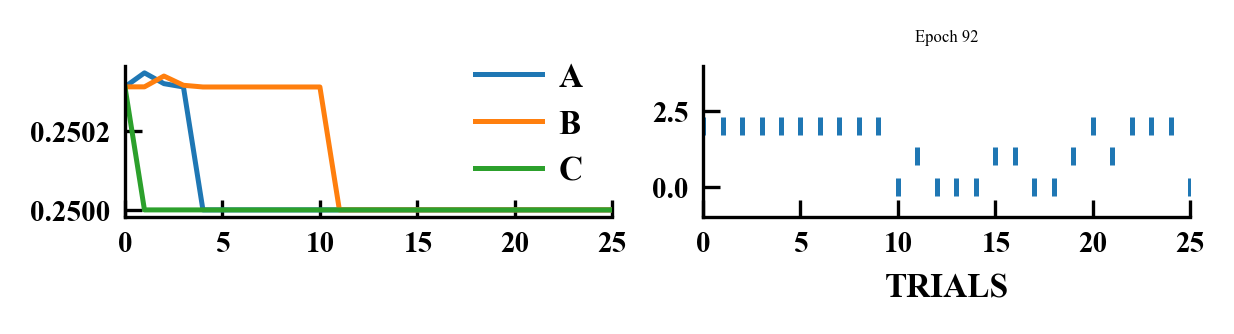

In [23]:
plt.figure(figsize=(4,1))
plt.subplot(1,2,1)
plt.plot(dp_monitor[0][0].squeeze().detach().numpy(), label = 'A')
plt.plot(dp_monitor[0][1].squeeze().detach().numpy(), label = 'B')
plt.plot(dp_monitor[0][2].squeeze().detach().numpy(), label = 'C')
plt.xlim(0,25)
plt.legend()
colors = np.where(np.isin(arm_chosen_monitor[e],[0,1]), 'r', 'g')
plt.subplot(1,2,2)
plt.scatter(np.arange(TRIALS), arm_chosen_monitor[e], marker = '|', s = 20)
plt.ylim(-1,4)
plt.xlim(0,25)
plt.xlabel('TRIALS')
plt.title(f'Epoch {e}', fontsize = 4)
i+=1